In [3]:
import pandas as pd
df = pd.read_csv("data/sample_emails.csv")
df.head()


,id,sender,subject,body,priority,label
0,1,hr@company.com,Offer Letter - Please Sign,"Dear Candidate, Congratulations! Please sign a...",high,important
1,2,noreply@shopping.com,Big Billion Sale is Live,Flat 70% OFF on electronics. Limited period of...,low,promotion
2,3,alerts@mybank.com,Unusual Login Attempt,We detected a login attempt to your account fr...,high,security
3,4,newsletter@blog.com,Weekly Tech Newsletter,"In this week's edition, learn about AI agents,...",low,newsletter
4,5,friend123@gmail.com,Coffee this weekend?,"Hey, long time no see! Are you free this weeke...",medium,personal


In [2]:
import os
os.chdir(r"C:\Users\Prana\OneDrive\Documents\GitHub\infosys-langgraph-email-assistant-group2")
print(os.getcwd())


C:\Users\Prana\OneDrive\Documents\GitHub\infosys-langgraph-email-assistant-group2


In [4]:
df.isnull().sum()


id          0
sender      0
subject     0
body        0
priority    0
label       0
dtype: int64

In [7]:
df["label"].value_counts()

label
work          2
promotion     1
important     1
security      1
newsletter    1
personal      1
spam          1
Name: count, dtype: int64

In [4]:
# Handle missing values
df['subject'] = df['subject'].fillna('').str.strip()
df['body'] = df['body'].fillna('').str.strip()

# Create cleaned lowercase versions
df['subject_clean'] = df['subject'].str.lower()
df['body_clean'] = df['body'].str.lower()

df.head()

,id,sender,subject,body,priority,label,subject_clean,body_clean
0,1,hr@company.com,Offer Letter - Please Sign,"Dear Candidate, Congratulations! Please sign a...",high,important,offer letter - please sign,"dear candidate, congratulations! please sign a..."
1,2,noreply@shopping.com,Big Billion Sale is Live,Flat 70% OFF on electronics. Limited period of...,low,promotion,big billion sale is live,flat 70% off on electronics. limited period of...
2,3,alerts@mybank.com,Unusual Login Attempt,We detected a login attempt to your account fr...,high,security,unusual login attempt,we detected a login attempt to your account fr...
3,4,newsletter@blog.com,Weekly Tech Newsletter,"In this week's edition, learn about AI agents,...",low,newsletter,weekly tech newsletter,"in this week's edition, learn about ai agents,..."
4,5,friend123@gmail.com,Coffee this weekend?,"Hey, long time no see! Are you free this weeke...",medium,personal,coffee this weekend?,"hey, long time no see! are you free this weeke..."


In [5]:
df.columns

Index(['id', 'sender', 'subject', 'body', 'priority', 'label', 'subject_clean',
       'body_clean'],
      dtype='object')

In [6]:
df['combined_text'] = df['subject'] + " " + df['body']
df[['subject', 'body', 'combined_text']].head()

,subject,body,combined_text
0,Offer Letter - Please Sign,"Dear Candidate, Congratulations! Please sign a...","Offer Letter - Please Sign Dear Candidate, Con..."
1,Big Billion Sale is Live,Flat 70% OFF on electronics. Limited period of...,Big Billion Sale is Live Flat 70% OFF on elect...
2,Unusual Login Attempt,We detected a login attempt to your account fr...,Unusual Login Attempt We detected a login atte...
3,Weekly Tech Newsletter,"In this week's edition, learn about AI agents,...","Weekly Tech Newsletter In this week's edition,..."
4,Coffee this weekend?,"Hey, long time no see! Are you free this weeke...","Coffee this weekend? Hey, long time no see! Ar..."


In [7]:
df[df['combined_text'].str.contains("offer", case=False)]

,id,sender,subject,body,priority,label,subject_clean,body_clean,combined_text
0,1,hr@company.com,Offer Letter - Please Sign,"Dear Candidate, Congratulations! Please sign a...",high,important,offer letter - please sign,"dear candidate, congratulations! please sign a...","Offer Letter - Please Sign Dear Candidate, Con..."
1,2,noreply@shopping.com,Big Billion Sale is Live,Flat 70% OFF on electronics. Limited period of...,low,promotion,big billion sale is live,flat 70% off on electronics. limited period of...,Big Billion Sale is Live Flat 70% OFF on elect...


In [8]:
df[df['priority'] == "high"]

,id,sender,subject,body,priority,label,subject_clean,body_clean,combined_text
0,1,hr@company.com,Offer Letter - Please Sign,"Dear Candidate, Congratulations! Please sign a...",high,important,offer letter - please sign,"dear candidate, congratulations! please sign a...","Offer Letter - Please Sign Dear Candidate, Con..."
2,3,alerts@mybank.com,Unusual Login Attempt,We detected a login attempt to your account fr...,high,security,unusual login attempt,we detected a login attempt to your account fr...,Unusual Login Attempt We detected a login atte...
5,6,spam@strange-domain.ru,"You won $1,000,000!!!",Click here to claim your lottery now. Do not s...,high,spam,"you won $1,000,000!!!",click here to claim your lottery now. do not s...,"You won $1,000,000!!! Click here to claim your..."
6,7,manager@company.com,Project Update Required,Please share the status update of your project...,high,work,project update required,please share the status update of your project...,Project Update Required Please share the statu...


In [9]:
df[df['label'] == "work"]

,id,sender,subject,body,priority,label,subject_clean,body_clean,combined_text
6,7,manager@company.com,Project Update Required,Please share the status update of your project...,high,work,project update required,please share the status update of your project...,Project Update Required Please share the statu...
7,8,training@lms.com,Reminder: Complete Mandatory Training,Your mandatory security awareness training is ...,medium,work,reminder: complete mandatory training,your mandatory security awareness training is ...,Reminder: Complete Mandatory Training Your man...


In [10]:
df[df['sender'].str.contains("hr", case=False)]

,id,sender,subject,body,priority,label,subject_clean,body_clean,combined_text
0,1,hr@company.com,Offer Letter - Please Sign,"Dear Candidate, Congratulations! Please sign a...",high,important,offer letter - please sign,"dear candidate, congratulations! please sign a...","Offer Letter - Please Sign Dear Candidate, Con..."


In [11]:
# Clean text
df['subject'] = df['subject'].fillna('').str.strip().str.lower()
df['body'] = df['body'].fillna('').str.strip().str.lower()

# Combine subject + body
df['combined_text'] = df['subject'] + " " + df['body']

In [12]:
def extract_priority(text):
    text = text.lower()

    if "high priority" in text or "urgent" in text or "immediately" in text:
        return "high"
    elif "medium priority" in text or "normal" in text:
        return "medium"
    elif "low priority" in text or "not urgent" in text:
        return "low"
    else:
        return "unknown"

In [13]:
# Clean priority column
df['priority'] = df['priority'].str.strip().str.lower()

df[['subject', 'priority']].head()

,subject,priority
0,offer letter - please sign,high
1,big billion sale is live,low
2,unusual login attempt,high
3,weekly tech newsletter,low
4,coffee this weekend?,medium


In [14]:
df.describe(include="all")

,id,sender,subject,body,priority,label,subject_clean,body_clean,combined_text
count,8.00000,8,8,8,8,8,8,8,8
unique,NaN,8,8,8,3,7,8,8,8
top,NaN,hr@company.com,offer letter - please sign,"dear candidate, congratulations! please sign a...",high,work,offer letter - please sign,"dear candidate, congratulations! please sign a...","offer letter - please sign dear candidate, con..."
freq,NaN,1,1,1,4,2,1,1,1
mean,4.50000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,2.44949,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,1.00000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,2.75000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,4.50000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,6.25000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
df["label"].value_counts()
                "# Ensure required NLTK packages and imports, create clean_txt if missing,",
                "# compute top words, and demonstrate stemming/tokenization robustly",
                "import nltk",
                "nltk.download('punkt', quiet=True)",
                "nltk.download('stopwords', quiet=True)",
                "nltk.download('wordnet', quiet=True)",
                "from nltk.stem import PorterStemmer",
                "from nltk.tokenize import word_tokenize",
                "from nltk.corpus import stopwords",
                "# Create/ensure clean_txt column (safe: do nothing if already present)",
                "if 'clean_txt' not in df.columns:",
                "    df['clean_txt'] = df['body'].fillna('').str.lower().str.replace('[^a-zA-Z ]','', regex=True)",
                "# Word frequency (safe handling of non-string rows)",
                "from collections import Counter",
                "all_words = ' '.join(df['clean_txt'].astype(str))",
                "word_list = all_words.split()",
                "word_freq = Counter(word_list)",
                "print('Top 15 words:', word_freq.most_common(15))",
                "# Example: tokenization + stemming over subject+body",
                "stemmer = PorterStemmer()",
                "all_text = ' '.join((df['subject'].fillna('') + ' ' + df['body'].fillna('')).astype(str))",
                "tokens = word_tokenize(all_text.lower())",
                "stemmed_words = [stemmer.stem(w) for w in tokens if w.isalpha()]",
                "print('Sample stemmed words:', stemmed_words[:50])"
<VSCode.Cell id="#VSC-701e155f" language="python">
df.shape
df.columns

label
work          2
promotion     1
important     1
security      1
newsletter    1
personal      1
spam          1
Name: count, dtype: int64

In [17]:
df.isnull().sum()

id               0
sender           0
subject          0
body             0
priority         0
label            0
subject_clean    0
body_clean       0
combined_text    0
dtype: int64

In [24]:
df['clean_txt'] = df['body'].str.lower().str.replace('[^a-zA-Z ]','', regex=True)


In [25]:
df['priority'].value_counts()

priority
high      4
low       2
medium    2
Name: count, dtype: int64

In [26]:
print(df.shape)  

(8, 10)


In [17]:
from collections import Counter
all_words = "".join(df['clean_txt'])
word_list = all_words.split()
word_freq = Counter(word_list)
word_freq.most_common(15)


[('your', 5),
 ('this', 4),
 ('please', 2),
 ('and', 2),
 ('offer', 2),
 ('a', 2),
 ('to', 2),
 ('not', 2),
 ('you', 2),
 ('share', 2),
 ('dear', 1),
 ('candidate', 1),
 ('congratulations', 1),
 ('sign', 1),
 ('upload', 1)]

In [9]:
pip install nltk

Note: you may need to restart the kernel to use updated packages.


In [19]:
import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords
stop_words = set(stopwords.words('english'))
filtered_words = [w for w in words if w not in stop_words]

[nltk_data] Downloading package stopwords to
[nltk_data]     c:\Users\Prana\OneDrive\Documents\GitHub\infosys-
[nltk_data]     langgraph-email-assistant-group2\.venv\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


NameError: name 'words' is not defined

In [26]:
# 1. Get all text
all_text = " ".join(df['clean_txt'])
# 2. Split into words
words = all_text.split()
# 3. Import NLTK stopwords
import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords
stop_words = set(stopwords.words('english'))
# 4. Filter
filtered_words = [w for w in words if w not in stop_words]
filtered_words[:20]   # show first few

[nltk_data] Downloading package stopwords to
[nltk_data]     c:\Users\Prana\OneDrive\Documents\GitHub\infosys-
[nltk_data]     langgraph-email-assistant-group2\.venv\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


['dear',
 'candidate',
 'congratulations',
 'please',
 'sign',
 'upload',
 'offer',
 'letter',
 'today',
 'evening',
 'flat',
 'electronics',
 'limited',
 'period',
 'offer',
 'visit',
 'store',
 'detected',
 'login',
 'attempt']

In [5]:
from nltk.stem import WordNetLemmatizer
from nltk.corpus import wordnet
import nltk
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\Prana\AppData\Roaming\nltk_data...
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\Prana\AppData\Roaming\nltk_data...


True

In [31]:
from nltk.stem import PorterStemmer
from nltk.tokenize import word_tokenize
import nltk
nltk.download('punkt')
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to
[nltk_data]     c:\Users\Prana\OneDrive\Documents\GitHub\infosys-
[nltk_data]     langgraph-email-assistant-group2\.venv\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     c:\Users\Prana\OneDrive\Documents\GitHub\infosys-
[nltk_data]     langgraph-email-assistant-group2\.venv\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt_tab.zip.
[nltk_data]   Unzipping tokenizers\punkt_tab.zip.


True

In [32]:
stemmer = PorterStemmer()
all_text = " ".join((df['subject'].fillna('') + ' ' + df['body'].fillna('')).astype(str))
tokens = word_tokenize(all_text.lower())
stemmed_words = [stemmer.stem(w) for w in tokens if w.isalpha()]
print(stemmed_words)

['offer', 'letter', 'pleas', 'sign', 'dear', 'candid', 'congratul', 'pleas', 'sign', 'and', 'upload', 'your', 'offer', 'letter', 'by', 'today', 'even', 'big', 'billion', 'sale', 'is', 'live', 'flat', 'off', 'on', 'electron', 'limit', 'period', 'offer', 'visit', 'our', 'store', 'now', 'unusu', 'login', 'attempt', 'we', 'detect', 'a', 'login', 'attempt', 'to', 'your', 'account', 'from', 'a', 'new', 'devic', 'if', 'thi', 'wa', 'not', 'you', 'pleas', 'reset', 'your', 'password', 'weekli', 'tech', 'newslett', 'in', 'thi', 'week', 'edit', 'learn', 'about', 'ai', 'agent', 'langgraph', 'and', 'more', 'coffe', 'thi', 'weekend', 'hey', 'long', 'time', 'no', 'see', 'are', 'you', 'free', 'thi', 'weekend', 'for', 'coffe', 'you', 'won', 'click', 'here', 'to', 'claim', 'your', 'lotteri', 'now', 'do', 'not', 'share', 'thi', 'with', 'anyon', 'project', 'updat', 'requir', 'pleas', 'share', 'the', 'statu', 'updat', 'of', 'your', 'project', 'befor', 'pm', 'today', 'remind', 'complet', 'mandatori', 'train'

In [34]:
# 1. Get all text
all_text = " ".join(df['clean_txt'])
# 2. Split into words
words = all_text.split()
# 3. Import NLTK stopwords
import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords
stop_words = set(stopwords.words('english'))
# 4. Filter
filtered_words = [w for w in words if w not in stop_words]
filtered_words[:20]   # show first few
from nltk.probability import FreqDist
fdist = FreqDist(filtered_words)
# Top 20 keywords
keywords = fdist.most_common(20)
print(keywords)


[('please', 3), ('offer', 2), ('today', 2), ('share', 2), ('dear', 1), ('candidate', 1), ('congratulations', 1), ('sign', 1), ('upload', 1), ('letter', 1), ('evening', 1), ('flat', 1), ('electronics', 1), ('limited', 1), ('period', 1), ('visit', 1), ('store', 1), ('detected', 1), ('login', 1), ('attempt', 1)]


[nltk_data] Downloading package stopwords to
[nltk_data]     c:\Users\Prana\OneDrive\Documents\GitHub\infosys-
[nltk_data]     langgraph-email-assistant-group2\.venv\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [35]:
df["combined"] = (df["subject"] + " " + df["body"]).str.lower()
categories = {
    "important": ["offer", "offer letter", "please sign", "upload"],
    "promotion": ["sale", "off", "discount", "flat", "limited period"],
    "security": ["login", "login attempt", "account", "password", "detected"],
    "newsletter": ["newsletter", "weekly", "edition", "subscribe"],
    "personal": ["coffee", "weekend", "hey", "long time"],
    "spam": ["won", "lottery", "claim", "click here", "prize"],
    "work": ["project", "status update", "please share", "reminder", "training"]
}
def detect_simple(text):
    text = text.lower()
    matches = []
    for cat, keys in categories.items():
        for k in keys:
            if k in text:
                matches.append(cat)
                break
    return matches

df["matched"] = df["combined"].apply(detect_simple)
df["num_matches"] = df["matched"].apply(len)
df[["id","subject","matched","num_matches"]]
from collections import Counter
category_counts = Counter()
for lst in df["matched"]:
    for c in lst:
        category_counts[c] += 1

category_counts  # dict-like; shows counts per category



Counter({'promotion': 3,
         'important': 2,
         'work': 2,
         'security': 1,
         'newsletter': 1,
         'personal': 1,
         'spam': 1})

Matplotlib is building the font cache; this may take a moment.


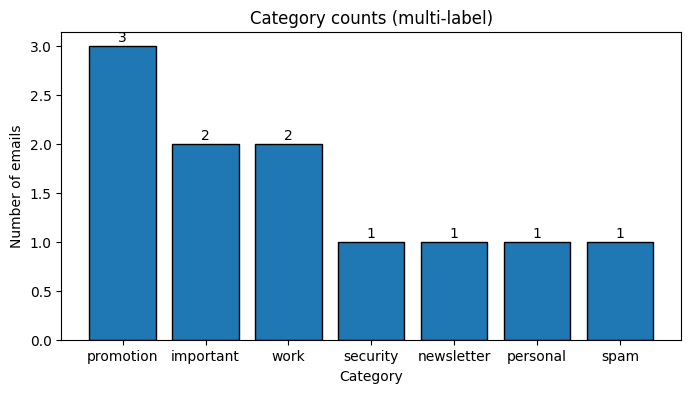

In [44]:
import matplotlib.pyplot as plt
# sort by count
items = sorted(category_counts.items(), key=lambda x: x[1], reverse=True)
cats = [i[0] for i in items]
vals = [i[1] for i in items]
plt.figure(figsize=(8,4))
bars = plt.bar(cats, vals, edgecolor='k')
plt.title("Category counts (multi-label)")
plt.xlabel("Category")
plt.ylabel("Number of emails")
for b in bars:
    plt.text(b.get_x()+b.get_width()/2, b.get_height()+0.05, int(b.get_height()), ha='center')
plt.show()

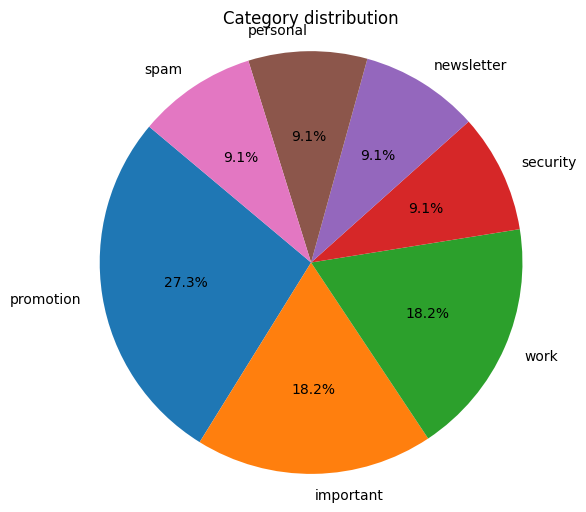

In [45]:
plt.figure(figsize=(6,6))
plt.pie(vals, labels=cats, autopct="%1.1f%%", startangle=140)
plt.title("Category distribution")
plt.axis("equal")
plt.show()


In [46]:
import re
# small English stopword set (expand if needed)
stopwords = {
 "the","and","is","in","to","of","for","a","an","by","on","this","that","with","your","please","we","our"
}
top5_per_category = {}
for cat in categories:
    texts = df[df["matched"].apply(lambda L: cat in L)]["combined"].tolist()
    words = []
    for t in texts:
        tokens = re.findall(r"\b[a-z]{2,}\b", t)   # only alphabetic tokens len>=2
        tokens = [w for w in tokens if w not in stopwords]
        words.extend(tokens)
    freq = Counter(words)
    top5 = [w for w,_ in freq.most_common(5)]
    top5_per_category[cat] = top5
top5_per_category

{'important': ['offer', 'letter', 'sign', 'dear', 'candidate'],
 'promotion': ['offer', 'letter', 'sign', 'coffee', 'weekend'],
 'security': ['login', 'attempt', 'unusual', 'detected', 'account'],
 'newsletter': ['weekly', 'tech', 'newsletter', 'week', 'edition'],
 'personal': ['coffee', 'weekend', 'hey', 'long', 'time'],
 'spam': ['you', 'won', 'click', 'here', 'claim'],
 'work': ['project', 'update', 'mandatory', 'training', 'required']}

In [47]:
multi = df[df["num_matches"] > 1][["id","sender","subject","matched","combined"]]
if multi.empty:
    print("No emails with multiple category matches.")
else:
    print(multi.to_string(index=False))

 id               sender                    subject                matched                                                                                                               combined
  1       hr@company.com Offer Letter - Please Sign [important, promotion] offer letter - please sign dear candidate, congratulations! please sign and upload your offer letter by today evening.
  2 noreply@shopping.com   Big Billion Sale is Live [important, promotion]                       big billion sale is live flat 70% off on electronics. limited period offer. visit our store now.
  5  friend123@gmail.com       Coffee this weekend?  [promotion, personal]                                      coffee this weekend? hey, long time no see! are you free this weekend for coffee?
